# OpenCows2020 Dataset Analysis

**Dataset:** OpenCows2020 (detection and localisation subset)  
**Notebook:** `notebooks/dataset_analysis/analysis_opencows2020.ipynb`  
**Output:** `results/analysis/opencows2020_summary.json`

Derives all statistics from `data/raw/opencow2020/` only. No pipeline outputs are read.


In [1]:
import sys, json, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path("../..")
RAW = REPO_ROOT / "data" / "raw" / "opencow2020" / "detection_and_localisation"
ANN_DIR = RAW / "ann"
IMG_DIR = RAW / "img"
RESULTS_DIR = REPO_ROOT / "results" / "analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ann_files = sorted(ANN_DIR.glob("*.json"))
img_files = sorted(IMG_DIR.glob("*.jpg"))

print("RAW path:", RAW.resolve())
print(f"Annotation files: {len(ann_files):,}")
print(f"Image files:      {len(img_files):,}")

RAW path: /home/sakif/TXST/Thesis/cattle-vision-framework/data/raw/opencow2020/detection_and_localisation
Annotation files: 7,043
Image files:      7,043


---

## 1. Dataset Overview

**Origin:** OpenCows2020 is a Holstein-Friesian cattle dataset collected at a UK dairy farm (University of Bristol). Images were captured from a fixed overhead camera positioned above a walkway, providing a top-down view of individual cows. The dataset was released to support research in cattle detection and identity re-identification via deep metric learning.

**Paper:** _"Visual Identification of Individual Holstein Friesian Cattle via Deep Metric Learning"_ (Andrew et al., 2020, CVPR Workshop). The original paper targets individual cattle re-identification; this analysis uses the **detection and localisation** subset only.

**License:** Available via DatasetNinja (academic use).

**Annotation format:** DatasetNinja/Supervisely JSON — one `.jpg.json` file per image at `detection_and_localisation/ann/{id}.jpg.json`. Each file contains a `size` dict (`height`, `width`) and an `objects` list; each object has `classTitle = 'cow'` and `points.exterior` (two corner coordinates `[[x1, y1], [x2, y2]]`). Object tags include `cow_id` (individual identity) and `non-synthetic`/`synthetic` flags.

**Single detection class:** `cow` — bounding box around each visible cow body from an overhead viewpoint.

**No train/val/test split:** The detection_and_localisation subset is a single flat collection of 7,043 images. There is no pre-defined split in the source data.

**Distinctive visual characteristic:** Top-down overhead view of a narrow walkway. Holstein-Friesian black-and-white coat pattern viewed from above. Cows appear one or two at a time in the frame, typically in motion.

**Role in thesis pipeline (Phase 8):**

- **Detection mAP** — OOD generalization test for RF-DETR trained on CBVD-5 + CVB
- **No behavior labels** — this dataset is detection + identity only; behavior classification is out of scope
- **No tracking evaluation** — no temporal sequence structure in the released detection subset


---

## 2. Data Inventory


In [2]:
n_boxes = 0
boxes_per_image = []
synthetic_count = 0

for f in ann_files:
    d = json.loads(f.read_text())
    boxes = [o for o in d["objects"] if o.get("classTitle") == "cow"]
    n_boxes += len(boxes)
    boxes_per_image.append(len(boxes))
    tag_names = {t["name"] for t in d.get("tags", [])}
    if "synthetic" in tag_names:
        synthetic_count += 1

total_images = len(ann_files)
total_boxes = n_boxes

print(f"Total images:         {total_images:,}")
print(f"Total boxes:          {total_boxes:,}")
print(f"Avg boxes per image:  {np.mean(boxes_per_image):.2f}")
print(f"Max boxes per image:  {max(boxes_per_image)}")
print(f"Synthetic images:     {synthetic_count:,}")
print(f"Non-synthetic images: {total_images - synthetic_count:,}")
print()
print("Image format:      .jpg")
print("Annotation format: DatasetNinja/Supervisely JSON (.jpg.json per image)")
print("Single class:      'cow' (detection bounding box only)")
print("Split structure:   None — single flat collection, no pre-defined train/val/test")

Total images:         7,043
Total boxes:          13,026
Avg boxes per image:  1.85
Max boxes per image:  10
Synthetic images:     3,336
Non-synthetic images: 3,707

Image format:      .jpg
Annotation format: DatasetNinja/Supervisely JSON (.jpg.json per image)
Single class:      'cow' (detection bounding box only)
Split structure:   None — single flat collection, no pre-defined train/val/test


---

## 3. Sample Image Visualization


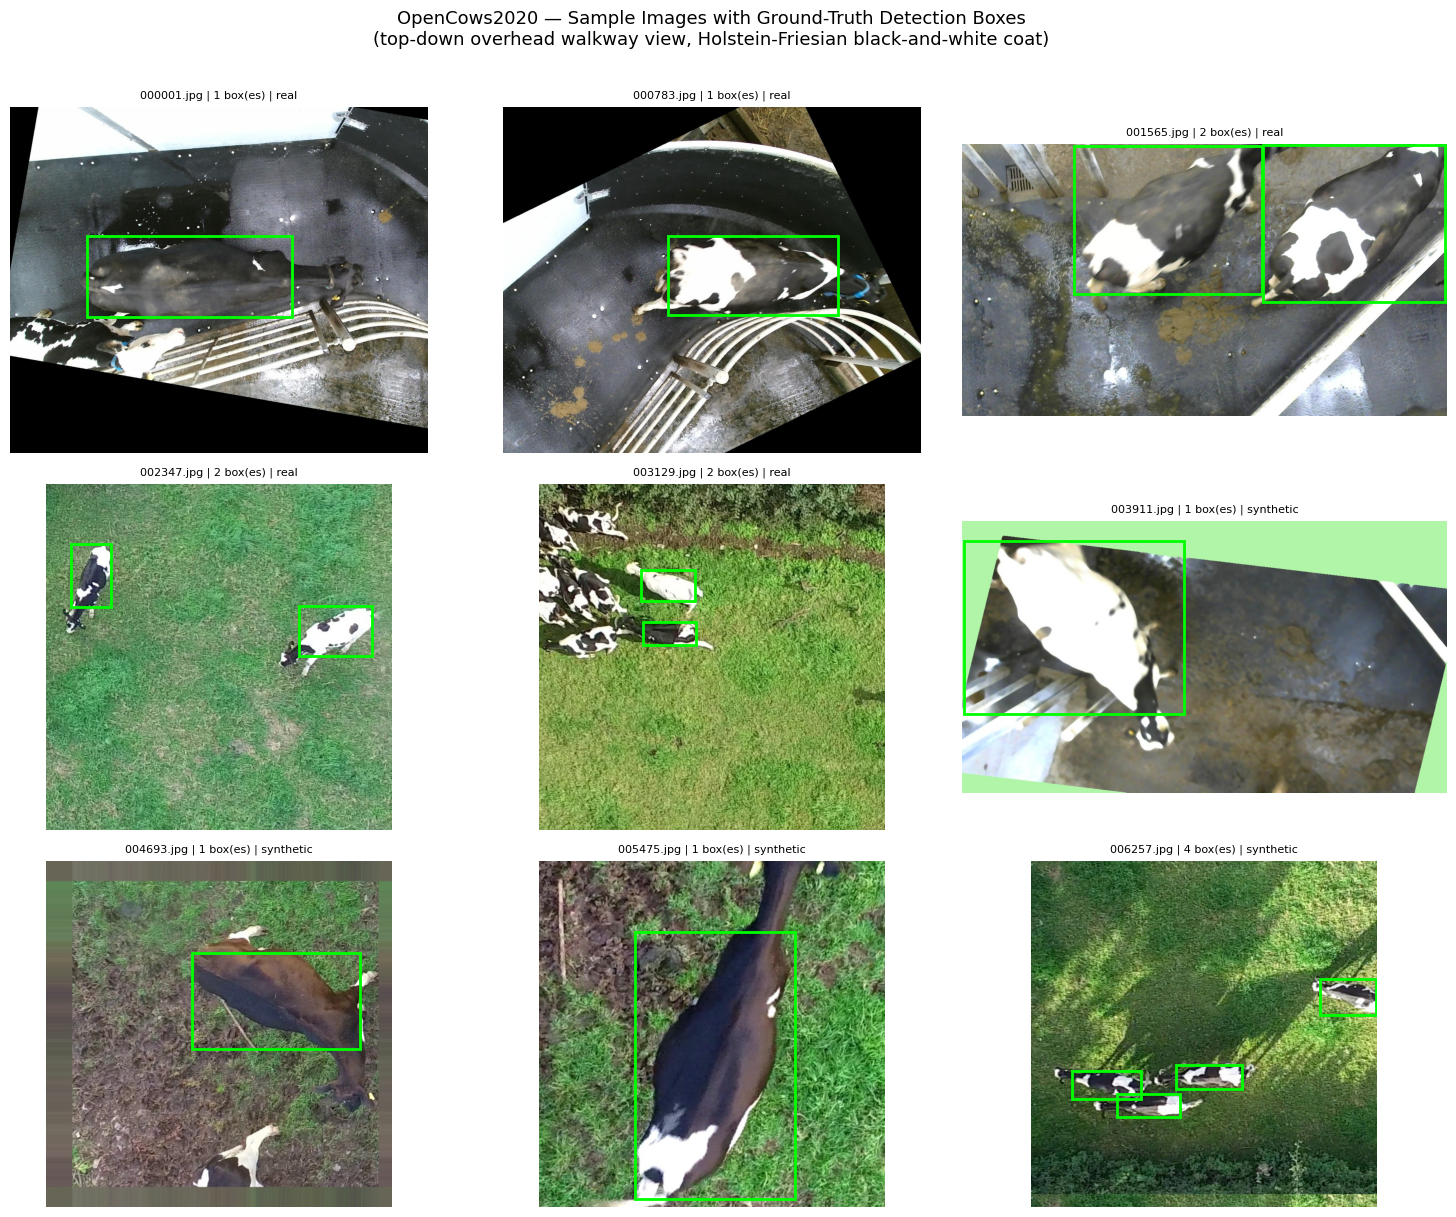

Saved: results/analysis/opencows2020_sample_frames.png


In [3]:
# Pick 9 images evenly spaced across the dataset and draw bounding boxes
n_samples = 9
step = max(1, len(ann_files) // n_samples)
sample_entries = ann_files[::step][:n_samples]

n_cols = 3
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle(
    "OpenCows2020 — Sample Images with Ground-Truth Detection Boxes\n"
    "(top-down overhead walkway view, Holstein-Friesian black-and-white coat)",
    fontsize=13,
    y=1.01,
)

for ax, ann_file in zip(axes.flat, sample_entries):
    img_path = IMG_DIR / ann_file.name.replace(".json", "")
    if not img_path.exists():
        ax.set_title(f"[missing] {img_path.name}", fontsize=8)
        ax.axis("off")
        continue

    img = Image.open(img_path)
    d = json.loads(ann_file.read_text())
    boxes = [o for o in d["objects"] if o.get("classTitle") == "cow"]

    # Tag for synthetic vs. non-synthetic
    tag_names = {t["name"] for t in d.get("tags", [])}
    synth_label = "synthetic" if "synthetic" in tag_names else "real"

    ax.imshow(img)
    for obj in boxes:
        (x1, y1), (x2, y2) = obj["points"]["exterior"]
        rect = plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2
        )
        ax.add_patch(rect)

    ax.set_title(f"{ann_file.stem} | {len(boxes)} box(es) | {synth_label}", fontsize=8)
    ax.axis("off")

for ax in axes.flat[n_samples:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "opencows2020_sample_frames.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: results/analysis/opencows2020_sample_frames.png")

---

## 4. Annotation Format


In [4]:
# Parse one sample annotation file and display its structure
sample_ann_path = ann_files[0]
d = json.loads(sample_ann_path.read_text())

print(f"=== Supervisely JSON: {sample_ann_path.name} ===")
print()
print(f"Top-level keys:    {list(d.keys())}")
print(f"Image size:        {d['size']['width']}×{d['size']['height']} px (W×H)")
print(f"Objects count:     {len(d['objects'])}")
print(f"Top-level tags:    {[t['name'] for t in d.get('tags', [])]}")
print()
if d["objects"]:
    obj0 = d["objects"][0]
    print("Sample object entry (objects[0]):")
    for k, v in obj0.items():
        print(f"  {k:<18} = {v}")
print()
print("Key fields:")
print("  classTitle         — always 'cow' (single detection class)")
print("  points.exterior    — [[x1, y1], [x2, y2]] absolute pixel coordinates")
print("  geometryType       — 'rectangle'")
print(
    "  tags (object-level)— cow_id: individual identity label (for re-ID, not used here)"
)
print()
print("Image-level tags:")
print("  non-synthetic      — image is a real photograph")
print("  synthetic          — image is synthetically generated (GAN augmentation)")
print()
print("Filename convention: {frame_id}.jpg.json")
print("  frame_id is a zero-padded 6-digit integer (000001–007043)")
print("  Corresponding image: detection_and_localisation/img/{frame_id}.jpg")

=== Supervisely JSON: 000001.jpg.json ===

Top-level keys:    ['description', 'tags', 'size', 'objects']
Image size:        1486×1230 px (W×H)
Objects count:     1
Top-level tags:    ['non-synthetic']

Sample object entry (objects[0]):
  id                 = 26802320
  classId            = 48701
  description        = 
  geometryType       = rectangle
  labelerLogin       = gr@datasetninja.com
  createdAt          = 2023-09-03T16:46:31.276Z
  updatedAt          = 2023-09-03T16:46:31.276Z
  tags               = []
  classTitle         = cow
  points             = {'exterior': [[275, 459], [1003, 747]], 'interior': []}

Key fields:
  classTitle         — always 'cow' (single detection class)
  points.exterior    — [[x1, y1], [x2, y2]] absolute pixel coordinates
  geometryType       — 'rectangle'
  tags (object-level)— cow_id: individual identity label (for re-ID, not used here)

Image-level tags:
  non-synthetic      — image is a real photograph
  synthetic          — image is synthetica

---

## 5. Class Distribution (Detection Box Counts)


In [5]:
print("Detection annotation class distribution — 'cow' boxes")
print()
print(f"{'Metric':<35} {'Value':>10}")
print("-" * 48)
print(f"{'Total images':<35} {total_images:>10,}")
print(f"{'Total boxes':<35} {total_boxes:>10,}")
print(f"{'Avg boxes per image':<35} {np.mean(boxes_per_image):>10.2f}")
print(f"{'Median boxes per image':<35} {np.median(boxes_per_image):>10.2f}")
print(f"{'Max boxes per image':<35} {max(boxes_per_image):>10}")
print(f"{'Images with 0 boxes (background)':<35} {boxes_per_image.count(0):>10,}")
print(f"{'Images with 1 box':<35} {boxes_per_image.count(1):>10,}")
print(f"{'Images with 2+ boxes':<35} {sum(1 for b in boxes_per_image if b >= 2):>10,}")
print()
print("Note: All boxes belong to the single class 'cow'.")
print("      No behavior labels are present in this dataset.")

Detection annotation class distribution — 'cow' boxes

Metric                                   Value
------------------------------------------------
Total images                             7,043
Total boxes                             13,026
Avg boxes per image                       1.85
Median boxes per image                    1.00
Max boxes per image                         10
Images with 0 boxes (background)             4
Images with 1 box                        3,901
Images with 2+ boxes                     3,138

Note: All boxes belong to the single class 'cow'.
      No behavior labels are present in this dataset.


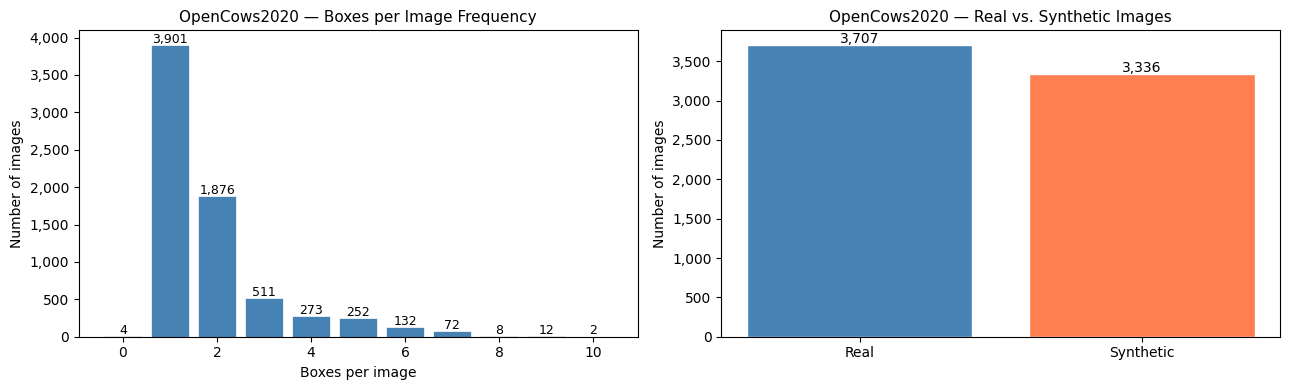

Saved: results/analysis/opencows2020_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart of boxes-per-image frequency
ax = axes[0]
max_boxes = max(boxes_per_image)
counts = collections.Counter(boxes_per_image)
x_vals = range(0, max_boxes + 1)
y_vals = [counts[x] for x in x_vals]
bars = ax.bar(x_vals, y_vals, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Boxes per image", fontsize=10)
ax.set_ylabel("Number of images", fontsize=10)
ax.set_title("OpenCows2020 — Boxes per Image Frequency", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar, count in zip(bars, y_vals):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f"{count:,}",
            ha="center",
            fontsize=9,
        )

# Right: real vs synthetic breakdown
ax2 = axes[1]
real_count = total_images - synthetic_count
labels = ["Real", "Synthetic"]
sizes = [real_count, synthetic_count]
colors = ["steelblue", "coral"]
bars2 = ax2.bar(labels, sizes, color=colors, edgecolor="white")
ax2.set_ylabel("Number of images", fontsize=10)
ax2.set_title("OpenCows2020 — Real vs. Synthetic Images", fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar, count in zip(bars2, sizes):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}",
        ha="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "opencows2020_class_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: results/analysis/opencows2020_class_distribution.png")

---

## 6. Resolution & Quality


In [7]:
# Collect resolutions from annotation JSONs (sample every 50th for speed)
resolutions: collections.Counter = collections.Counter()
sample_count = 0
for f in ann_files[::50]:
    d = json.loads(f.read_text())
    resolutions[(d["size"]["width"], d["size"]["height"])] += 1
    sample_count += 1

dominant_res = resolutions.most_common(1)[0][0]
print(f"Sampled {sample_count} annotation files")
print(f"Unique resolutions found: {len(resolutions)}")
print("Resolution breakdown:")
for res, cnt in resolutions.most_common():
    pct = 100 * cnt / sample_count
    print(f"  {res[0]}×{res[1]}  ({cnt} sampled, ~{pct:.0f}%)")
print(f"Dominant resolution: {dominant_res[0]}×{dominant_res[1]} px (W×H)")

print()
print("Bounding box size statistics (all images, pixels):")
box_widths = []
box_heights = []
box_areas = []
img_widths_for_boxes = []
img_heights_for_boxes = []

for f in ann_files:
    d = json.loads(f.read_text())
    W = d["size"]["width"]
    H = d["size"]["height"]
    for obj in d["objects"]:
        if obj.get("classTitle") == "cow":
            (x1, y1), (x2, y2) = obj["points"]["exterior"]
            w = abs(x2 - x1)
            h = abs(y2 - y1)
            box_widths.append(w)
            box_heights.append(h)
            box_areas.append(w * h)
            img_widths_for_boxes.append(W)
            img_heights_for_boxes.append(H)

img_areas = [iw * ih for iw, ih in zip(img_widths_for_boxes, img_heights_for_boxes)]
rel_areas = [ba / ia for ba, ia in zip(box_areas, img_areas)]

print(
    f"  Box width  — min={min(box_widths):.0f}  max={max(box_widths):.0f}  mean={np.mean(box_widths):.1f}  median={np.median(box_widths):.1f}"
)
print(
    f"  Box height — min={min(box_heights):.0f}  max={max(box_heights):.0f}  mean={np.mean(box_heights):.1f}  median={np.median(box_heights):.1f}"
)
print(
    f"  Box area   — min={min(box_areas):.0f}  max={max(box_areas):.0f}  mean={np.mean(box_areas):.0f}  median={np.median(box_areas):.0f}"
)
print(f"  Avg box as % of image area: {100 * np.mean(rel_areas):.1f}%")

Sampled 141 annotation files
Unique resolutions found: 10
Resolution breakdown:
  1280×720  (45 sampled, ~32%)
  1486×1230  (33 sampled, ~23%)
  733×733  (33 sampled, ~23%)
  732×733  (7 sampled, ~5%)
  733×732  (6 sampled, ~4%)
  1536×864  (5 sampled, ~4%)
  733×735  (5 sampled, ~4%)
  735×733  (4 sampled, ~3%)
  732×735  (2 sampled, ~1%)
  732×732  (1 sampled, ~1%)
Dominant resolution: 1280×720 px (W×H)

Bounding box size statistics (all images, pixels):
  Box width  — min=3  max=1018  mean=347.8  median=307.0
  Box height — min=1  max=1022  mean=243.5  median=230.0
  Box area   — min=152  max=900201  mean=109075  median=83010
  Avg box as % of image area: 10.5%


In [8]:
# Image / annotation pairing check
on_disk = {p.stem for p in IMG_DIR.glob("*.jpg")}
missing = 0
for f in ann_files:
    img_stem = Path(f.name.replace(".json", "")).stem  # e.g. '000001'
    if img_stem not in on_disk:
        missing += 1

print(f"Annotation files checked: {len(ann_files):,}")
print(f"Images on disk:           {len(img_files):,}")
print(f"Missing images:           {missing:,}")
if missing == 0:
    print("\n✅ Every annotation file has a matching .jpg image.")
else:
    print(f"\n⚠️  {missing} annotation files have no matching image.")

Annotation files checked: 7,043
Images on disk:           7,043
Missing images:           0

✅ Every annotation file has a matching .jpg image.


---

## 7. Evaluation Scope

> **This dataset has no behavior labels. It is used exclusively for detection mAP evaluation in Phase 8.**

| Evaluation task          | In scope | Notes                                                        |
| ------------------------ | -------- | ------------------------------------------------------------ |
| Detection mAP            | ✅ Yes   | OOD test for RF-DETR trained on CBVD-5 + CVB                 |
| Short-term tracking IDF1 | ❌ No    | No temporal sequence structure in detection_and_localisation |
| Behavior classification  | ❌ No    | No behavior labels present                                   |
| Activity budgets         | ❌ No    | No behavior labels present                                   |
| Training                 | ❌ No    | Not used for model training                                  |

**Why this dataset matters for Phase 8:**  
OpenCows2020 provides a strong OOD detection challenge — the overhead walkway viewpoint, Holstein-Friesian coat pattern, and narrow field of view are all absent from CBVD-5 and CVB training images. A detection mAP evaluated here directly quantifies viewpoint and appearance generalization.

**Real vs. synthetic split consideration:**  
The dataset includes both real photographs and synthetically generated (GAN-augmented) images. For Phase 8 evaluation, the recommendation is to evaluate on real images only to avoid inflating mAP on synthetic examples that may not reflect real-world appearance variation.


In [9]:
print("Evaluation scope summary:")
print()
print("  Dataset role:         Phase 8 OOD detection-only evaluation")
print("  Behavior labels:      None")
print("  Detection class:      'cow' → directly compatible with RF-DETR class 0")
print(
    "  Split used for eval:  All images (no pre-defined split; use full set or real-only)"
)
print("  Training split:       NOT used for any model training")
print()
print("  OOD challenge factors:")
print(
    "    1. Camera viewpoint — overhead top-down walkway vs. side-view in training data"
)
print(
    "    2. Breed appearance — Holstein-Friesian black-and-white coat not in training"
)
print("    3. Frame composition — single or two cows per frame, narrow walkway")
print()
print("  Recommended eval subset: non-synthetic images only")
print(f"    Real images:      {total_images - synthetic_count:,}")
print(f"    Synthetic images: {synthetic_count:,} (exclude from mAP evaluation)")

Evaluation scope summary:

  Dataset role:         Phase 8 OOD detection-only evaluation
  Behavior labels:      None
  Detection class:      'cow' → directly compatible with RF-DETR class 0
  Split used for eval:  All images (no pre-defined split; use full set or real-only)
  Training split:       NOT used for any model training

  OOD challenge factors:
    1. Camera viewpoint — overhead top-down walkway vs. side-view in training data
    2. Breed appearance — Holstein-Friesian black-and-white coat not in training
    3. Frame composition — single or two cows per frame, narrow walkway

  Recommended eval subset: non-synthetic images only
    Real images:      3,707
    Synthetic images: 3,336 (exclude from mAP evaluation)


---

## 8. Preprocessing Gap Analysis


In [10]:
print("Preprocessing steps required before OpenCows2020 enters the Phase 8 pipeline:")
print()
print("1. Filter synthetic images (recommended)")
print("   - Read image-level 'tags' field; exclude images tagged 'synthetic'.")
print(
    f"   - Retains {total_images - synthetic_count:,} real images for mAP evaluation."
)
print()
print("2. Convert annotation format")
print("   - Supervisely JSON → YOLO .txt or COCO JSON for RF-DETR evaluation.")
print("   - Map classTitle 'cow' to class ID 0.")
print("   - Convert points.exterior [[x1,y1],[x2,y2]] → absolute [x1,y1,x2,y2] boxes.")
print()
print("3. Define evaluation split")
print("   - No pre-defined train/val/test split exists in source data.")
print("   - For Phase 8 detection mAP: use all real images as the evaluation set.")
print("   - Alternatively, create an 80/20 random split for a held-out test set.")
print()
print("4. Detection inference (script 06_run_detection.sh)")
print("   - Run RF-DETR on OpenCows2020 images to generate predictions.")
print("   - Compare predictions against ground-truth boxes for mAP computation.")
print()
print("5. No tracking or tubelet generation needed")
print("   - Images are not from labeled temporal sequences; tracking is out of scope.")
print("   - Behavior classification is out of scope for this dataset.")
print()
print("6. No label remapping needed")
print(
    "   - Single detection class 'cow' maps directly. No behavior taxonomy alignment."
)

Preprocessing steps required before OpenCows2020 enters the Phase 8 pipeline:

1. Filter synthetic images (recommended)
   - Read image-level 'tags' field; exclude images tagged 'synthetic'.
   - Retains 3,707 real images for mAP evaluation.

2. Convert annotation format
   - Supervisely JSON → YOLO .txt or COCO JSON for RF-DETR evaluation.
   - Map classTitle 'cow' to class ID 0.
   - Convert points.exterior [[x1,y1],[x2,y2]] → absolute [x1,y1,x2,y2] boxes.

3. Define evaluation split
   - No pre-defined train/val/test split exists in source data.
   - For Phase 8 detection mAP: use all real images as the evaluation set.
   - Alternatively, create an 80/20 random split for a held-out test set.

4. Detection inference (script 06_run_detection.sh)
   - Run RF-DETR on OpenCows2020 images to generate predictions.
   - Compare predictions against ground-truth boxes for mAP computation.

5. No tracking or tubelet generation needed
   - Images are not from labeled temporal sequences; trackin

---

## 9. Summary JSON + Self-Consistency Check


In [11]:
summary = {
    "dataset": "opencows2020",
    "total_images_or_frames": total_images,
    "total_annotations": total_boxes,
    "splits": {"train": 0, "val": 0, "test": 0},
    "class_distribution": {"cow": total_boxes},
    "resolution": {"width": dominant_res[0], "height": dominant_res[1]},
    "has_behavior_labels": False,
    "evaluation_scope": ["detection_map"],
}

# Schema validation
required_keys = [
    "dataset",
    "total_images_or_frames",
    "total_annotations",
    "splits",
    "class_distribution",
    "resolution",
    "has_behavior_labels",
    "evaluation_scope",
]
missing_keys = [k for k in required_keys if k not in summary]
assert not missing_keys, f"Missing schema keys: {missing_keys}"

non_int = {
    k: v
    for k, v in summary["class_distribution"].items()
    if not isinstance(v, int) or v <= 0
}
assert not non_int, f"class_distribution has invalid values: {non_int}"

out_path = RESULTS_DIR / "opencows2020_summary.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Summary JSON:")
print(json.dumps(summary, indent=2))
print(f"\n✅ Saved: {out_path}")

Summary JSON:
{
  "dataset": "opencows2020",
  "total_images_or_frames": 7043,
  "total_annotations": 13026,
  "splits": {
    "train": 0,
    "val": 0,
    "test": 0
  },
  "class_distribution": {
    "cow": 13026
  },
  "resolution": {
    "width": 1280,
    "height": 720
  },
  "has_behavior_labels": false,
  "evaluation_scope": [
    "detection_map"
  ]
}

✅ Saved: ../../results/analysis/opencows2020_summary.json


In [12]:
# Self-consistency check against known OpenCows2020 dataset statistics
print("Self-consistency check:")
print("=" * 70)

checks = [
    (
        "Total images",
        total_images,
        7043,
        "== 7043 (DatasetNinja / PRD)",
    ),
    (
        "Total boxes > 0",
        int(total_boxes > 0),
        1,
        "at least one box found",
    ),
    (
        "Distinct classes",
        len(summary["class_distribution"]),
        1,
        "== 1 ('cow' only)",
    ),
    (
        "No pre-defined splits",
        sum(summary["splits"].values()),
        0,
        "splits all zero (no split in source)",
    ),
    (
        "has_behavior_labels",
        int(summary["has_behavior_labels"]),
        0,
        "== False (detection only)",
    ),
    (
        "Missing images",
        missing,
        0,
        "== 0 (all annotation files have matching images)",
    ),
    (
        "Annotation files == image files",
        len(ann_files),
        len(img_files),
        f"ann={len(ann_files):,} == img={len(img_files):,}",
    ),
]

all_ok = True
for name, computed, expected, note in checks:
    ok = computed == expected
    status = "✅" if ok else "⚠️ "
    if not ok:
        all_ok = False
    print(f"{status} {name:<40} computed={computed:>7}  expected={expected:>7}  {note}")

print()
if all_ok:
    print("✅ All checks passed.")
else:
    print("⚠️  Some checks failed — review the values above.")

Self-consistency check:
✅ Total images                             computed=   7043  expected=   7043  == 7043 (DatasetNinja / PRD)
✅ Total boxes > 0                          computed=      1  expected=      1  at least one box found
✅ Distinct classes                         computed=      1  expected=      1  == 1 ('cow' only)
✅ No pre-defined splits                    computed=      0  expected=      0  splits all zero (no split in source)
✅ has_behavior_labels                      computed=      0  expected=      0  == False (detection only)
✅ Missing images                           computed=      0  expected=      0  == 0 (all annotation files have matching images)
✅ Annotation files == image files          computed=   7043  expected=   7043  ann=7,043 == img=7,043

✅ All checks passed.
